In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [6]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab/indexData.csv'
)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

  Index        Date        Open        High         Low       Close  \
0   NYA  1965-12-31  528.690002  528.690002  528.690002  528.690002   
1   NYA  1966-01-03  527.210022  527.210022  527.210022  527.210022   
2   NYA  1966-01-04  527.840027  527.840027  527.840027  527.840027   
3   NYA  1966-01-05  531.119995  531.119995  531.119995  531.119995   
4   NYA  1966-01-06  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  
0  528.690002     0.0  
1  527.210022     0.0  
2  527.840027     0.0  
3  531.119995     0.0  
4  532.070007     0.0  

Shape: (112457, 8)

Columns:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [7]:
df["Target"] = (
    df["Close"].shift(-1) > df["Close"]
).astype(int)

df = df.dropna(
    subset=["Open", "High", "Low", "Close", "Volume"]
)

df = df.iloc[:-1]

print(df.head())

print("\nTarget Distribution:")
print(df["Target"].value_counts())

  Index        Date        Open        High         Low       Close  \
0   NYA  1965-12-31  528.690002  528.690002  528.690002  528.690002   
1   NYA  1966-01-03  527.210022  527.210022  527.210022  527.210022   
2   NYA  1966-01-04  527.840027  527.840027  527.840027  527.840027   
3   NYA  1966-01-05  531.119995  531.119995  531.119995  531.119995   
4   NYA  1966-01-06  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  Target  
0  528.690002     0.0       0  
1  527.210022     0.0       1  
2  527.840027     0.0       1  
3  531.119995     0.0       1  
4  532.070007     0.0       1  

Target Distribution:
Target
1    57648
0    52604
Name: count, dtype: int64


In [8]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

X = df[features]

y = df["Target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
         Open        High         Low       Close  Volume
0  528.690002  528.690002  528.690002  528.690002     0.0
1  527.210022  527.210022  527.210022  527.210022     0.0
2  527.840027  527.840027  527.840027  527.840027     0.0
3  531.119995  531.119995  531.119995  531.119995     0.0
4  532.070007  532.070007  532.070007  532.070007     0.0

Target:
0    0
1    1
2    1
3    1
4    1
Name: Target, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (88201, 5)
Testing data: (22051, 5)


In [10]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [11]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1]


In [12]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Down", "Up"]
    )
)

Accuracy: 0.522878781007664

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.08      0.14     10496
          Up       0.53      0.92      0.67     11555

    accuracy                           0.52     22051
   macro avg       0.51      0.50      0.41     22051
weighted avg       0.51      0.52      0.42     22051



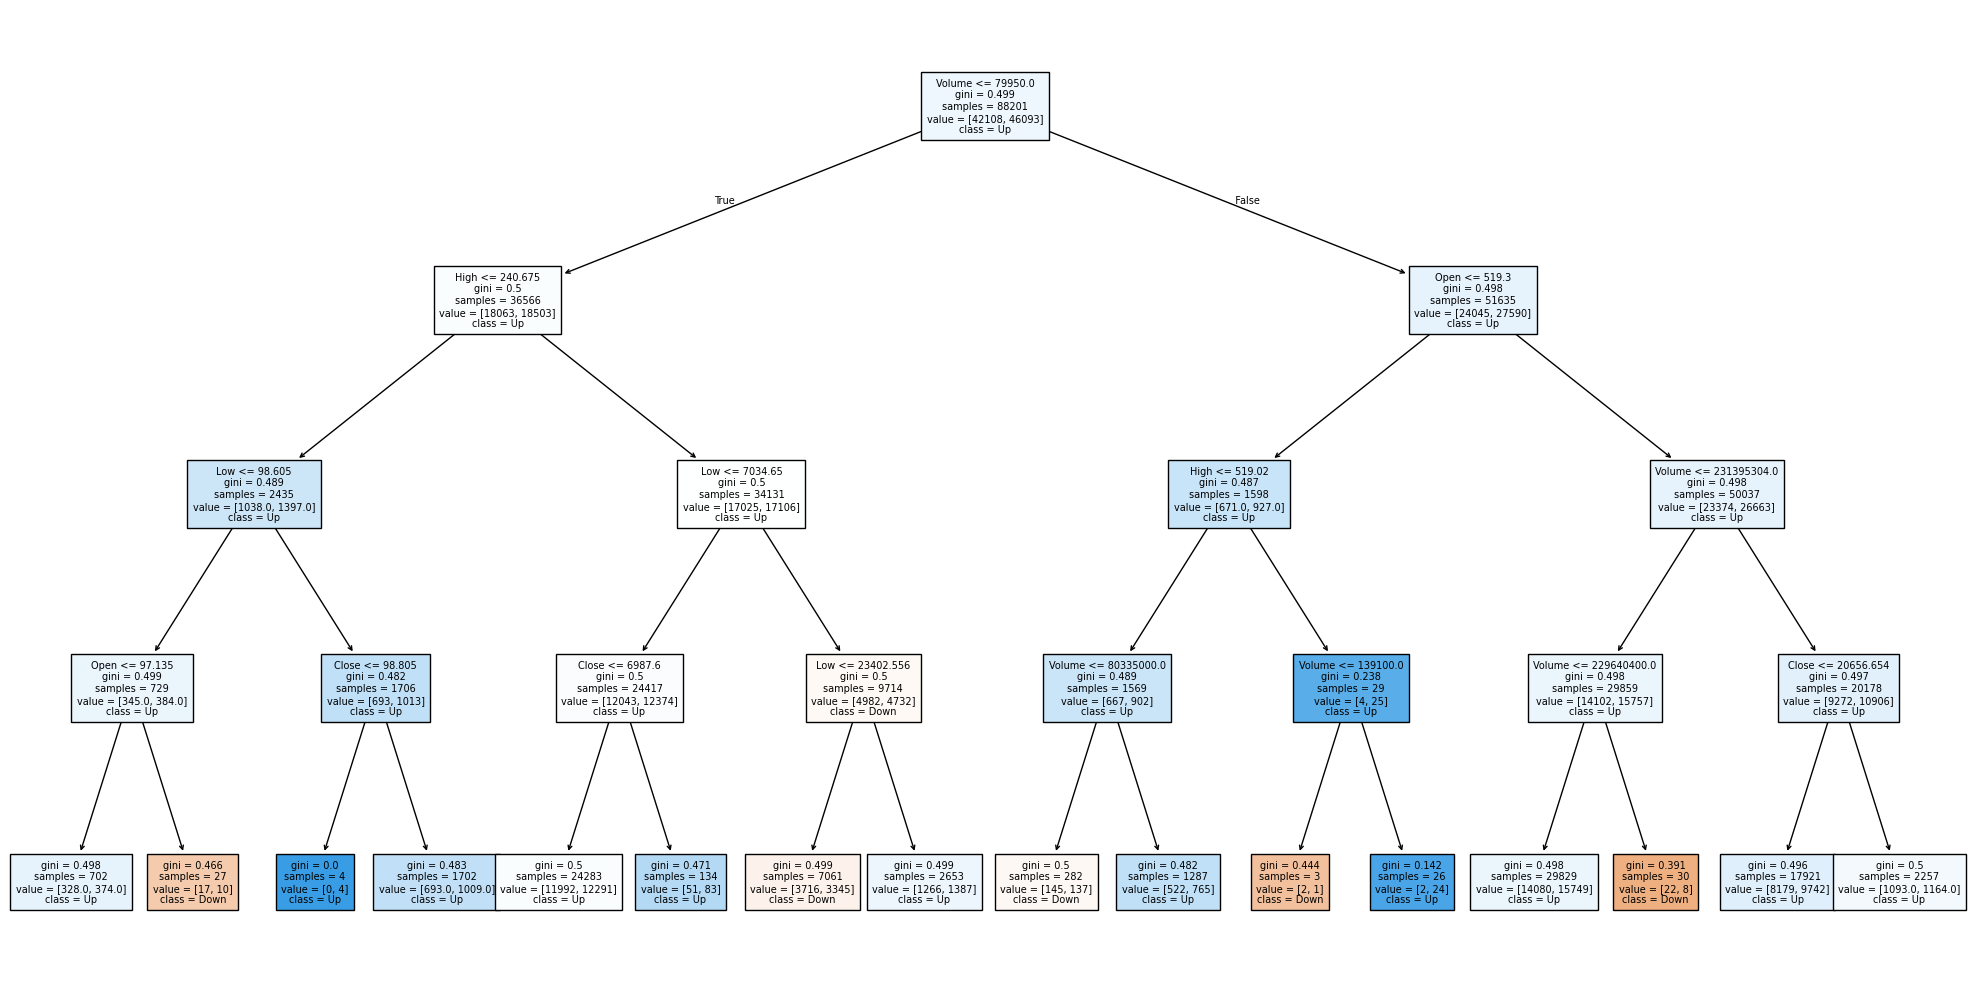

Saved tree image.


In [13]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Down", "Up"],
    filled=True,
    fontsize=7
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Colab/decision_tree_index.png',
    dpi=150
)

plt.show()

print("Saved tree image.")

In [14]:
RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(oob_score=True, random_state=42)

In [15]:
rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Down", "Up"]
    )
)

Random Forest Accuracy: 0.5085937145707677

Classification Report:
              precision    recall  f1-score   support

        Down       0.48      0.47      0.48     10496
          Up       0.53      0.55      0.54     11555

    accuracy                           0.51     22051
   macro avg       0.51      0.51      0.51     22051
weighted avg       0.51      0.51      0.51     22051



In [16]:
print(
    "Random Forest OOB Score:",
    rf.oob_score_
)

Random Forest OOB Score: 0.502363918776431


In [17]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
Close     0.216998
Open      0.216340
Low       0.215714
High      0.215168
Volume    0.135781
dtype: float64


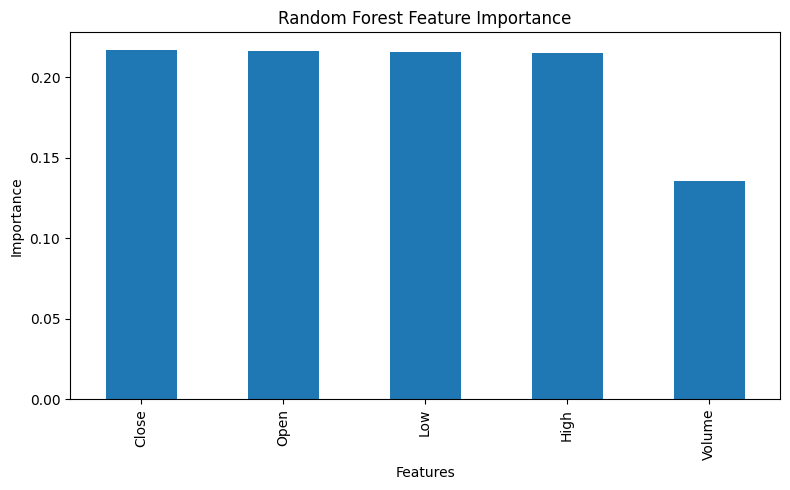

In [18]:
plt.figure(figsize=(8, 5))

importance.plot(
    kind="bar"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Colab/random_forest_importance.png',
    dpi=150
)

plt.show()

In [19]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest OOB Score:", rf.oob_score_)

Decision Tree Accuracy: 0.522878781007664
Random Forest Accuracy: 0.5085937145707677
Random Forest OOB Score: 0.502363918776431
